In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("powerplant_data.csv")

In [4]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [5]:
# AT => temperature
# V => vacuum
# AP => pressure
# RH => humidity

# PE => produced energy

In [6]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [7]:
X = df.drop("PE", axis=1)
y = df["PE"]

In [8]:
y.head()

0    480.48
1    445.75
2    438.76
3    453.09
4    464.43
Name: PE, dtype: float64

In [9]:
# Split out data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
df.shape

(9568, 5)

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
X_test_scaled

array([[ 1.34499288,  0.23869298, -1.28658067, -1.10532538],
       [ 0.81095912,  1.36269098, -0.74140656,  0.26485915],
       [-0.2437241 , -0.73900436,  1.99970178, -0.19713193],
       ...,
       [-0.67068342, -1.15902881, -0.29951077, -0.10651852],
       [ 1.31420898,  1.33752097, -0.87346737, -0.44288647],
       [-0.2611237 , -0.27021304,  0.37433797,  1.10646548]],
      shape=(1914, 4))

In [13]:
import torch
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

In [14]:
type(X_train_scaled)

numpy.ndarray

In [15]:
type(y_train)
y_train.shape

(7654,)

In [16]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [17]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

### Deep Learning

In [18]:
# Define our ANN Model

class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
            # 1st hidden layer
            nn.Linear(X_train.shape[1], 6),
            nn.ReLU(),
    
            # 2nd hidden layer
            nn.Linear(6, 6),
            nn.ReLU(),
    
            # output layer
            nn.Linear(6, 1),
        )

    def forward(self, x):
        return self.model(x)

In [21]:
import torch.optim as optim

model = ANN()

# loss, optimizer
crietrion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)

In [22]:
# Train the ANN
train_losses = []
val_losses = []

best_val_loss = float("inf")

epochs = 100

for epoch in range(epochs):
    model.train()
    running_loss = 0.0 # tot training loss for 1 epoch
    
    for xb, yb in train_loader:
        # xb = features of 1 batch
        # yb = labels of 1 batch
        optimizer.zero_grad()
        
        outputs = model(xb) # forward prop....predicted outputs for this batch
        loss = crietrion(outputs, yb) # compute loss
        loss.backward() # back prop.. compute gradients
        optimizer.step() # params update
        
        running_loss += loss.item() # loss is a tensor => py float

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)


    # Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad(): # no gradients compute
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = crietrion(outputs, yb)
            running_val_loss += loss

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    # print(f"epoch {epoch+1}/ {epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")


    if (epoch + 1) % 1 == 0:
       print(f"epoch {epoch+1}/ {epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt") #.pt or .pth

epoch 1/ 100 ==> train loss = 206252.8515625 & val loss = 205661.90625
epoch 2/ 100 ==> train loss = 204918.77467447918 & val loss = 203228.265625
epoch 3/ 100 ==> train loss = 200499.4197265625 & val loss = 196519.9375
epoch 4/ 100 ==> train loss = 191023.04296875 & val loss = 184216.765625
epoch 5/ 100 ==> train loss = 175798.83600260416 & val loss = 166207.40625
epoch 6/ 100 ==> train loss = 155261.07096354166 & val loss = 143504.203125
epoch 7/ 100 ==> train loss = 130897.783984375 & val loss = 118004.71875
epoch 8/ 100 ==> train loss = 105030.41399739584 & val loss = 92222.4140625
epoch 9/ 100 ==> train loss = 79964.66213378907 & val loss = 68739.3359375
epoch 10/ 100 ==> train loss = 58672.584635416664 & val loss = 49647.7265625
epoch 11/ 100 ==> train loss = 42181.84724121094 & val loss = 35998.6875
epoch 12/ 100 ==> train loss = 31255.630533854168 & val loss = 27404.443359375
epoch 13/ 100 ==> train loss = 24689.65088704427 & val loss = 22510.373046875
epoch 14/ 100 ==> train l

In [23]:
print(train_losses)
print(val_losses)

[206252.8515625, 204918.77467447918, 200499.4197265625, 191023.04296875, 175798.83600260416, 155261.07096354166, 130897.783984375, 105030.41399739584, 79964.66213378907, 58672.584635416664, 42181.84724121094, 31255.630533854168, 24689.65088704427, 21015.00898844401, 18764.536706542967, 17097.004337565104, 15540.959478759765, 14044.492736816406, 12575.467458089193, 11097.639154052735, 9660.946306355794, 8251.501389567058, 6955.912685139974, 5688.387033081055, 4561.811912027994, 3528.0363800048826, 2666.88083597819, 1960.3705660502117, 1416.7411524454753, 1017.6387677510579, 733.4744671503703, 532.0886408805848, 390.63473987579346, 288.8133380730947, 217.28142506281534, 166.94949226379396, 124.553115995725, 96.54805464744568, 74.66400402386984, 59.444464004039766, 48.1692230463028, 40.413846675554915, 34.65048858126004, 31.090142552057902, 28.081917349497477, 26.408020782470704, 24.92523348132769, 23.979805394013724, 23.25415908098221, 22.6708180030187, 22.286359206835428, 22.03231594959

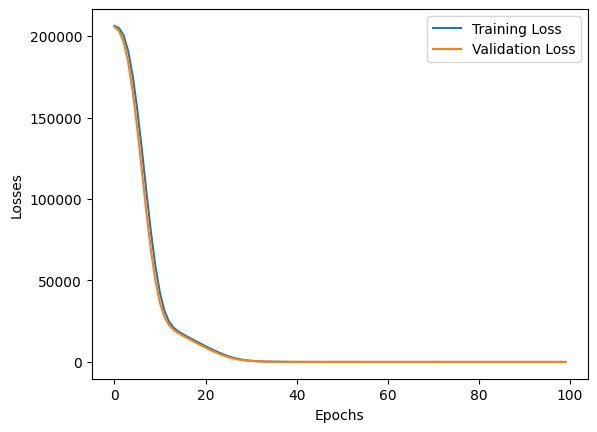

In [24]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses
})

plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [25]:
# Loading the best model
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [26]:
# Evaluation

model.eval()
with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor).squeeze() # remove extra dim

    train_mse_loss = crietrion(train_preds, y_train_tensor)
    test_mse_loss = crietrion(test_preds, y_test_tensor)

print("Training MSE:", train_mse_loss.item())
print("Testing MSE:", test_mse_loss.item())

Training MSE: 20.801694869995117
Testing MSE: 551.2052001953125


e:\Pytorch_ML\env\Lib\site-packages\torch\nn\modules\loss.py:626: UserWarning: Using a target size (torch.Size([1914, 1])) that is different to the input size (torch.Size([1914])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


In [27]:
from sklearn.metrics import r2_score

print("r^2 score =", r2_score(y_test, test_preds))

r^2 score = 0.9326621847058885


In [28]:
predicted_df = pd.DataFrame(test_preds.numpy(), columns=["Predicted Values"])
actual_df = pd.DataFrame(y_test.values, columns=["Actual Values"])

pd.concat([predicted_df, actual_df], axis=1)

,Predicted Values,Actual Values
0,435.367462,433.27
1,437.064575,438.16
2,461.071869,458.42
3,475.998932,480.82
4,435.283875,441.41
...,...,...
1909,451.381866,456.70
1910,431.768219,438.04
1911,467.511902,467.80
1912,431.208496,437.14
